# Week 3: Advanced Demand Forecasting using ARIMA

## Objective

The objective of Week 3 is to implement an ARIMA forecasting model using historical demand data, train and tune the model, generate future demand predictions for the next 90 days, and visualize the forecasted demand against historical trends.

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

##Load Dataset

In [ ]:
df = pd.read_excel("baseline_forecastingdataset.xlsx")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        731 non-null    datetime64[ns]
 1   Units Sold  731 non-null    int64         
 2   SMA_7       725 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 17.3 KB


##Convert Date ColumnConvert Date Column

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

##Sort Dataset

In [ ]:
df = df.sort_values("Date")

##Create Time Series

In [ ]:
daily_sales = (
    df.groupby("Date")["Units Sold"]
      .sum()
      .sort_index()
)

daily_sales.head()

,Units Sold
Date,
2022-01-01,14484
2022-01-02,13415
2022-01-03,13681
2022-01-04,14084
2022-01-05,12572


##Plot Historical Demand

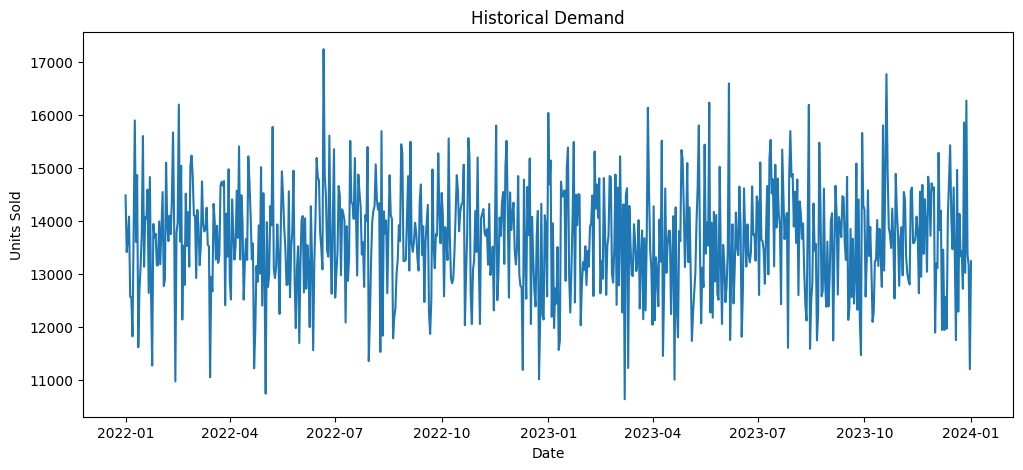

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Historical Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

##Split Train & Test

In [ ]:
train_size = int(len(daily_sales)*0.8)
train = daily_sales[:train_size]
test = daily_sales[train_size:]

##Train ARIMA

In [ ]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

##Predict Test Data

In [ ]:
forecast = model_fit.forecast(steps=len(test))

##Calculate Accuracy

In [ ]:
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
print("RMSE :", rmse)
print("MAPE :", mape)

RMSE : 1118.033758242124
MAPE : 0.0684437382032892


##Tune Parameters

In [ ]:
ARIMA(train, order=(1,1,1))
ARIMA(train, order=(2,1,2))
ARIMA(train, order=(5,1,0))

##Train Final Model

In [ ]:
final_model = ARIMA(daily_sales, order=(5,1,0))
final_model_fit = final_model.fit()

##Forecast Next 90 Days

In [ ]:
future_forecast = final_model_fit.forecast(steps=90)

##Create Future Dates

In [ ]:
future_dates = pd.date_range(
    start=daily_sales.index[-1] + pd.Timedelta(days=1),
    periods=90
)

##Save Future Forecast

In [ ]:
future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_forecast.values
})
future_df.to_excel("future_forecast.xlsx", index=False)

##Save Advanced Forecast

In [ ]:
advanced_forecast = pd.DataFrame({
    "Date": test.index,
    "Actual": test.values,
    "ARIMA_Prediction": forecast.values
})
advanced_forecast.to_excel("advanced_forecast.xlsx", index=False)

##Plot Actual vs ARIMA

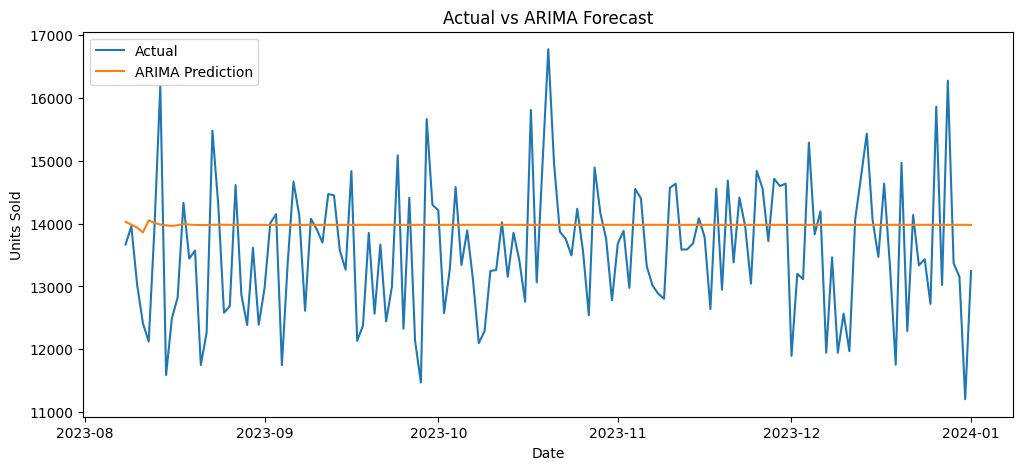

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test.values, label="Actual")

plt.plot(test.index, forecast.values, label="ARIMA Prediction")

plt.title("Actual vs ARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.show()

##Plot Future Forecast

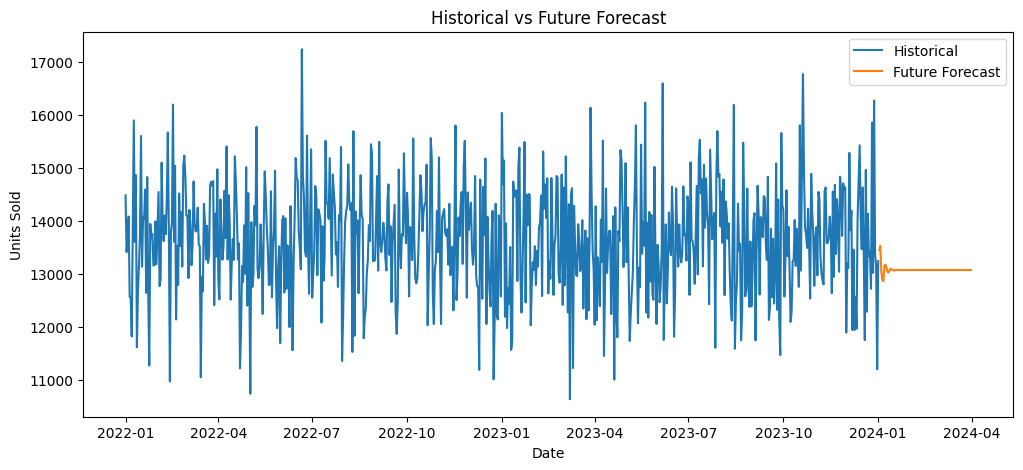

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(daily_sales, label="Historical")

plt.plot(future_dates, future_forecast, label="Future Forecast")

plt.title("Historical vs Future Forecast")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.show()



### Key Observations
- ARIMA successfully generated demand forecasts from historical Units Sold data.
- The selected ARIMA (5,1,0) model was used for the final forecast.
- A 90-day future demand forecast was generated.
- Forecast results were exported for further analysis.
- The advanced forecast can be compared with the SMA baseline to determine the better-performing forecasting approach.